# Policy Neural Network Analysis — `policy_1.pt`

This notebook dissects the MLP policy trained in `training.ipynb` (1 drone, 1 base, 6×6 grid).

We progressively "open the black box" by inspecting:
1. **Architecture & parameter count** per layer
2. **Weight / bias distributions** and near-zero statistics
3. **Activation distributions** via forward hooks on sample inputs
4. **Gradient-based saliency** — which input features drive each output action
5. **Neuron activation heatmaps** across a rollout trajectory
6. **Input perturbation / occlusion** feature importance
7. **PCA / t-SNE** of hidden representations coloured by interpretable quantities

---

**Input feature layout** (10 scalars fed to the first Linear layer):

| Index | Feature | Source |
|-------|---------|--------|
| 0 | drone x position | drone row |
| 1 | drone y position | drone row |
| 2 | drone velocity vx | drone row |
| 3 | drone velocity vy | drone row |
| 4 | drone battery | drone row |
| 5 | base x position | base row |
| 6 | base y position | base row |
| 7 | base feat-2 (≡ 0) | base row |
| 8 | base feat-3 (≡ 0) | base row |
| 9 | base occupancy | base row |

**Output** (2 scalars, scaled by `action_scale=2.0`):

| Index | Meaning |
|-------|---------|
| 0 | Δvx action |
| 1 | Δvy action |

## 1 · Import Libraries & Load Policy

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from policy.mlp_policy import DroneMLPPolicy, flatten_obs_for_mlp
from drone.config import ScenarioCfg
from drone.dynamics import step_dynamics_batched, _init_base_positions

# ── Scenario configuration (must match training.ipynb) ──────────────────────
GRID_SIDE   = 6
N_BASES     = 1
N_DRONES    = 1
N_FEAT      = 6
HIDDEN      = 128
ACTION_SCALE = 2.0

POLICY_PATH = 'policy_1.pt'

# ── Feature names (10 inputs) ────────────────────────────────────────────────
INPUT_NAMES = [
    'drone_x', 'drone_y', 'drone_vx', 'drone_vy', 'drone_battery',
    'base_x',  'base_y',  'base_f2',  'base_f3',  'base_occupancy',
]
OUTPUT_NAMES = ['action_vx', 'action_vy']

# ── Load ─────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

policy = DroneMLPPolicy(
    n_drones=N_DRONES,
    n_bases=N_BASES,
    n_feat=N_FEAT,
    hidden=HIDDEN,
    out_channels=2,
    action_scale=ACTION_SCALE,
).to(device)

policy.load_state_dict(torch.load(POLICY_PATH, map_location=device, weights_only=True))
policy.eval()

n_params = sum(p.numel() for p in policy.parameters())
print(f"Loaded policy from '{POLICY_PATH}'")
print(f"Total trainable parameters: {n_params:,}")

Loaded policy from 'policy_1.pt'
Total trainable parameters: 18,178


## 2 · Network Architecture Summary

In [2]:
print("=" * 60)
print("DroneMLPPolicy — layer-by-layer summary")
print("=" * 60)

in_dim  = N_DRONES * (N_FEAT - 1) + N_BASES * (N_FEAT - 1)   # 10
layer_in = in_dim

for name, module in policy.net.named_children():
    if isinstance(module, nn.Linear):
        w = module.weight
        b = module.bias
        out_dim = w.shape[0]
        print(f"\n  Linear  [{layer_in:>4} → {out_dim:>4}]   "
              f"weight {tuple(w.shape)}  bias {tuple(b.shape)}")
        print(f"    params: {w.numel() + b.numel():>7,}")
        layer_in = out_dim
    elif isinstance(module, nn.ReLU):
        print(f"  ReLU    [{layer_in}]")
    elif isinstance(module, nn.Tanh):
        print(f"  Tanh    [{layer_in}]")
    else:
        print(f"  {type(module).__name__}")

print(f"\n{'─'*60}")
print(f"  Total parameters: {n_params:,}")
print(f"  Input  shape:     ({in_dim},)  →  {INPUT_NAMES}")
print(f"  Output shape:     ({N_DRONES * 2},)  →  {OUTPUT_NAMES}")
print("=" * 60)

DroneMLPPolicy — layer-by-layer summary

  Linear  [  10 →  128]   weight (128, 10)  bias (128,)
    params:   1,408
  ReLU    [128]

  Linear  [ 128 →  128]   weight (128, 128)  bias (128,)
    params:  16,512
  ReLU    [128]

  Linear  [ 128 →    2]   weight (2, 128)  bias (2,)
    params:     258
  Tanh    [2]

────────────────────────────────────────────────────────────
  Total parameters: 18,178
  Input  shape:     (10,)  →  ['drone_x', 'drone_y', 'drone_vx', 'drone_vy', 'drone_battery', 'base_x', 'base_y', 'base_f2', 'base_f3', 'base_occupancy']
  Output shape:     (2,)  →  ['action_vx', 'action_vy']


## 3 · Weight & Bias Distribution per Layer

We examine the distribution of learned weights and biases. A very large fraction of near-zero weights can signal under-utilised neurons; a bimodal distribution suggests the network has learned structured filters.

Layer  0  | weight: mean=+0.0024 std=0.1840 min=-0.3775 max=0.3608 near-zero=4.1%
         | bias:   mean=-0.0023 std=0.1825 min=-0.3233 max=0.3159 near-zero=3.1%
Layer  2  | weight: mean=+0.0004 std=0.0563 min=-0.2125 max=0.2243 near-zero=11.1%
         | bias:   mean=-0.0025 std=0.0536 min=-0.0908 max=0.0904 near-zero=9.4%
Layer  4  | weight: mean=-0.0092 std=0.0618 min=-0.1531 max=0.1585 near-zero=9.4%
         | bias:   mean=+0.0099 std=0.0344 min=-0.0245 max=0.0443 near-zero=0.0%


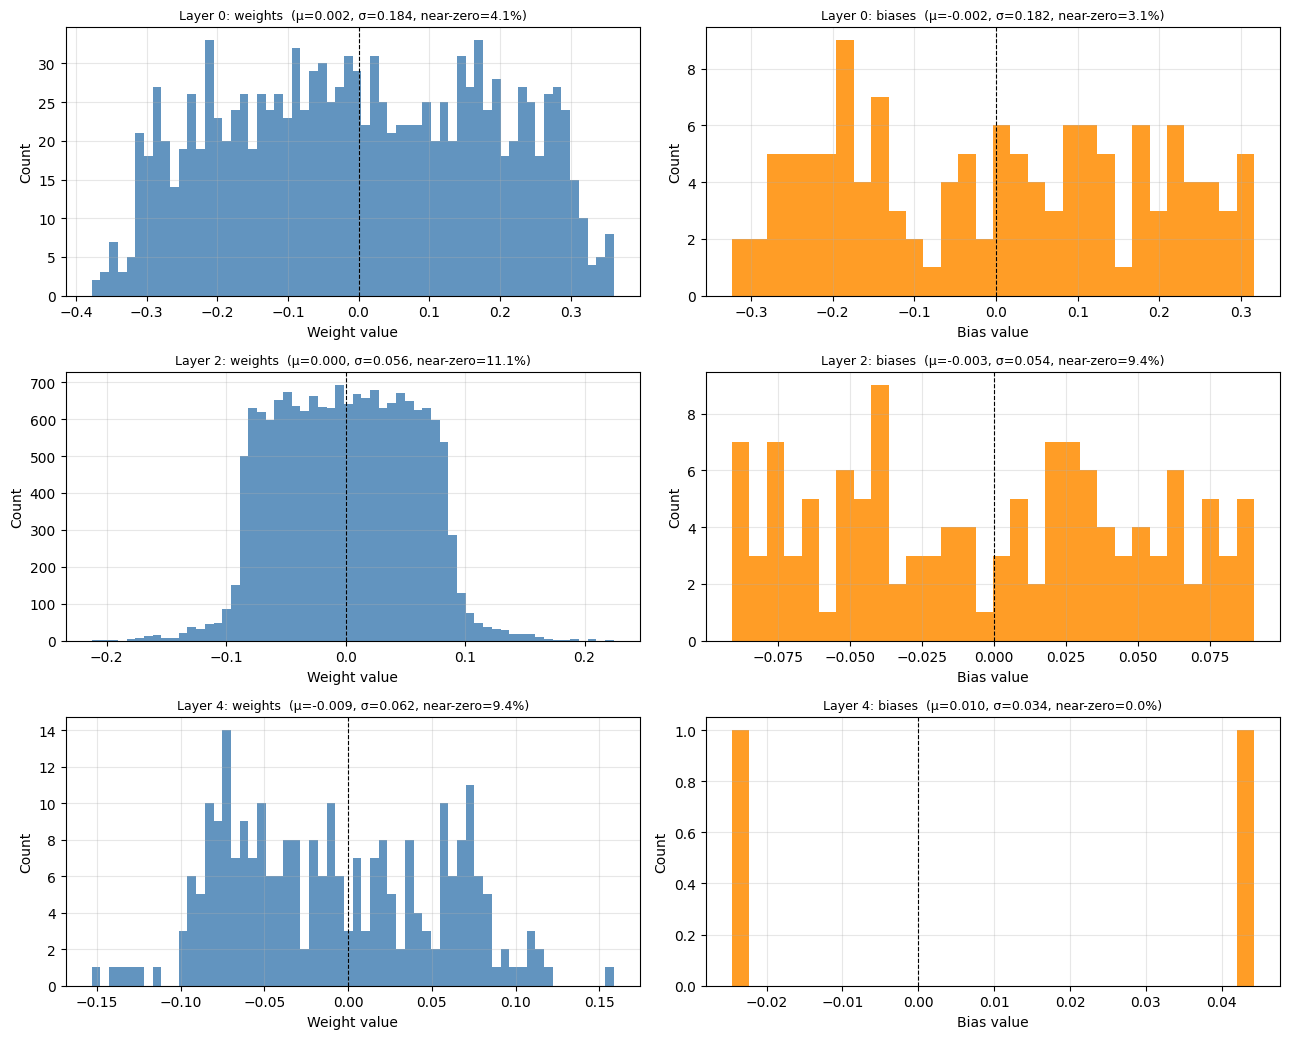

In [3]:
NEAR_ZERO_THRESHOLD = 0.01   # weights with |w| < this fraction are "near-zero"

linear_layers = [(name, m) for name, m in policy.net.named_children()
                 if isinstance(m, nn.Linear)]

fig, axes = plt.subplots(len(linear_layers), 2,
                         figsize=(13, 3.5 * len(linear_layers)))

for row, (name, lyr) in enumerate(linear_layers):
    w = lyr.weight.detach().cpu().numpy().ravel()
    b = lyr.bias.detach().cpu().numpy().ravel()

    nz_w = np.mean(np.abs(w) < NEAR_ZERO_THRESHOLD) * 100
    nz_b = np.mean(np.abs(b) < NEAR_ZERO_THRESHOLD) * 100

    ax_w, ax_b = axes[row]

    ax_w.hist(w, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    ax_w.axvline(0, color='k', lw=0.8, ls='--')
    ax_w.set_title(
        f'Layer {name}: weights  '
        f'(µ={w.mean():.3f}, σ={w.std():.3f}, '
        f'near-zero={nz_w:.1f}%)', fontsize=9)
    ax_w.set_xlabel('Weight value')
    ax_w.set_ylabel('Count')
    ax_w.grid(alpha=0.3)

    ax_b.hist(b, bins=30, color='darkorange', edgecolor='none', alpha=0.85)
    ax_b.axvline(0, color='k', lw=0.8, ls='--')
    ax_b.set_title(
        f'Layer {name}: biases  '
        f'(µ={b.mean():.3f}, σ={b.std():.3f}, '
        f'near-zero={nz_b:.1f}%)', fontsize=9)
    ax_b.set_xlabel('Bias value')
    ax_b.set_ylabel('Count')
    ax_b.grid(alpha=0.3)

    print(f"Layer {name:>2}  | weight: mean={w.mean():+.4f} std={w.std():.4f} "
          f"min={w.min():.4f} max={w.max():.4f} near-zero={nz_w:.1f}%")
    print(f"         | bias:   mean={b.mean():+.4f} std={b.std():.4f} "
          f"min={b.min():.4f} max={b.max():.4f} near-zero={nz_b:.1f}%")

plt.tight_layout()
plt.show()

## 4 · Activation Analysis on Sample Inputs

We register forward hooks on every layer, run a large grid of scenario inputs, and plot the post-activation distributions. Neurons with activation ≡ 0 across the whole dataset are **dead neurons**.

Sample batch: torch.Size([4500, 10])


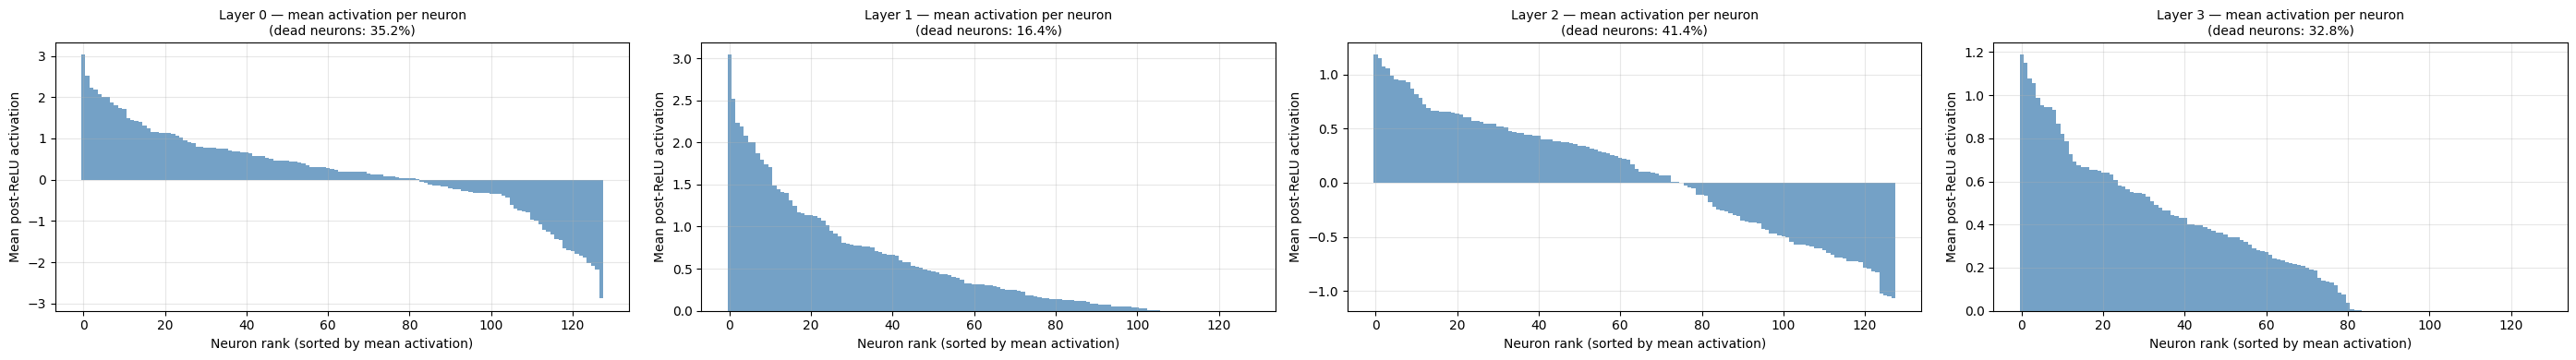


Dead neuron analysis (mean activation across full batch < 1e-6):
  Layer 0: 45/128 dead neurons (35.2%)
  Layer 1: 21/128 dead neurons (16.4%)
  Layer 2: 53/128 dead neurons (41.4%)
  Layer 3: 42/128 dead neurons (32.8%)


In [4]:
# ── Build a diverse batch of flattened inputs ────────────────────────────────
# Sweep drone (x,y) on the grid and battery levels; fix base at centre of grid.
N   = 30          # grid resolution per spatial dimension
N_B = 5           # battery levels to sweep
xs  = np.linspace(1, GRID_SIDE, N)
ys  = np.linspace(1, GRID_SIDE, N)
batts = np.linspace(0.05, 1.0, N_B)

rows = []
BASE_X, BASE_Y = GRID_SIDE / 2.0, GRID_SIDE / 2.0  # fixed base position
for batt in batts:
    for x in xs:
        for y in ys:
            rows.append([x, y, 0.0, 0.0, batt,
                         BASE_X, BASE_Y, 0.0, 0.0, 0.0])   # occupancy=0

sample_inputs = torch.tensor(rows, dtype=torch.float32, device=device)  # (N*N*N_B, 10)
print(f"Sample batch: {sample_inputs.shape}")

# ── Register hooks ───────────────────────────────────────────────────────────
activations: dict[str, np.ndarray] = {}
hooks = []

def _make_hook(layer_name: str):
    def hook(module, inp, out):
        activations[layer_name] = out.detach().cpu().numpy()
    return hook

for name, module in policy.net.named_children():
    h = module.register_forward_hook(_make_hook(name))
    hooks.append(h)

with torch.no_grad():
    _ = policy.net(sample_inputs)

for h in hooks:
    h.remove()   # always clean up

# ── Plot post-activation distributions for ReLU layers only ─────────────────
relu_acts = {k: v for k, v in activations.items()
             if v.ndim == 2 and v.shape[1] == HIDDEN}

fig, axes = plt.subplots(1, len(relu_acts), figsize=(7 * len(relu_acts), 4), squeeze=False)

for col, (lname, act) in enumerate(relu_acts.items()):
    ax = axes[0][col]
    # per-neuron mean activation across the batch
    mean_act = act.mean(axis=0)
    dead_frac = np.mean(mean_act < 1e-6) * 100

    ax.bar(np.arange(HIDDEN), np.sort(mean_act)[::-1],
           color='steelblue', alpha=0.75, width=1)
    ax.set_title(f'Layer {lname} — mean activation per neuron\n'
                 f'(dead neurons: {dead_frac:.1f}%)', fontsize=10)
    ax.set_xlabel('Neuron rank (sorted by mean activation)')
    ax.set_ylabel('Mean post-ReLU activation')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Dead neuron summary ──────────────────────────────────────────────────────
print("\nDead neuron analysis (mean activation across full batch < 1e-6):")
for lname, act in relu_acts.items():
    mean_act = act.mean(axis=0)
    dead = int(np.sum(mean_act < 1e-6))
    print(f"  Layer {lname}: {dead}/{HIDDEN} dead neurons ({dead/HIDDEN*100:.1f}%)")

## 5 · Input Sensitivity via Gradient-Based Saliency

For each output action dimension, we compute $\left|\frac{\partial a_k}{\partial x_i}\right|$ averaged over the sample batch. This shows which input features the network "pays attention to" when deciding each action component.

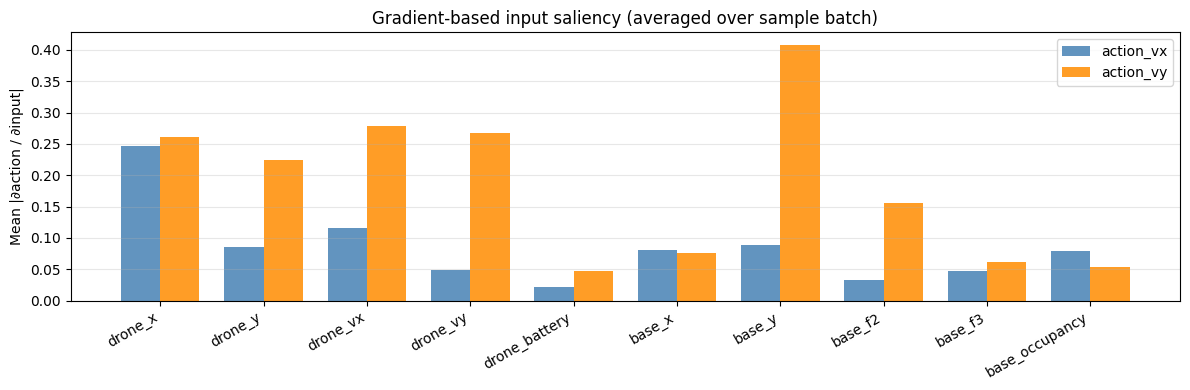


Feature importance ranking:
Feature                 ∇action_vx    ∇action_vy
────────────────────────────────────────────────
drone_x                    0.24728       0.26072
base_y                     0.08867       0.40780
drone_vx                   0.11633       0.27902
drone_vy                   0.04821       0.26825
drone_y                    0.08573       0.22387
base_f2                    0.03239       0.15637
base_x                     0.08020       0.07665
base_occupancy             0.07969       0.05326
base_f3                    0.04747       0.06245
drone_battery              0.02246       0.04787


In [5]:
inp = sample_inputs.clone().requires_grad_(True)   # (B, 10)

# Forward through the linear stack directly
out = policy.net(inp)          # (B, 2)  — tanh * ACTION_SCALE already applied

# Gradient of each output action w.r.t. every input feature
grad_vx = torch.autograd.grad(out[:, 0].sum(), inp, retain_graph=True)[0]  # (B, 10)
grad_vy = torch.autograd.grad(out[:, 1].sum(), inp)[0]                     # (B, 10)

saliency_vx = grad_vx.abs().mean(dim=0).detach().cpu().numpy()   # (10,)
saliency_vy = grad_vy.abs().mean(dim=0).detach().cpu().numpy()   # (10,)

# ── Plot ─────────────────────────────────────────────────────────────────────
x_pos = np.arange(len(INPUT_NAMES))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 4))
bars1 = ax.bar(x_pos - w/2, saliency_vx, width=w, label='action_vx', color='steelblue', alpha=0.85)
bars2 = ax.bar(x_pos + w/2, saliency_vy, width=w, label='action_vy', color='darkorange', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(INPUT_NAMES, rotation=30, ha='right')
ax.set_ylabel('Mean |∂action / ∂input|')
ax.set_title('Gradient-based input saliency (averaged over sample batch)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Ranked table ─────────────────────────────────────────────────────────────
print("\nFeature importance ranking:")
print(f"{'Feature':<20}  {'∇action_vx':>12}  {'∇action_vy':>12}")
print("─" * 48)
order = np.argsort(saliency_vx + saliency_vy)[::-1]
for i in order:
    print(f"{INPUT_NAMES[i]:<20}  {saliency_vx[i]:>12.5f}  {saliency_vy[i]:>12.5f}")

## 6 · Neuron Activation Heatmaps Across a Rollout

We run a full episode with the trained policy and record the hidden-layer pre-output activations at every time-step. The resulting **neurons × time** heatmap reveals how the network's internal state evolves as the drone moves, charges, and navigates.

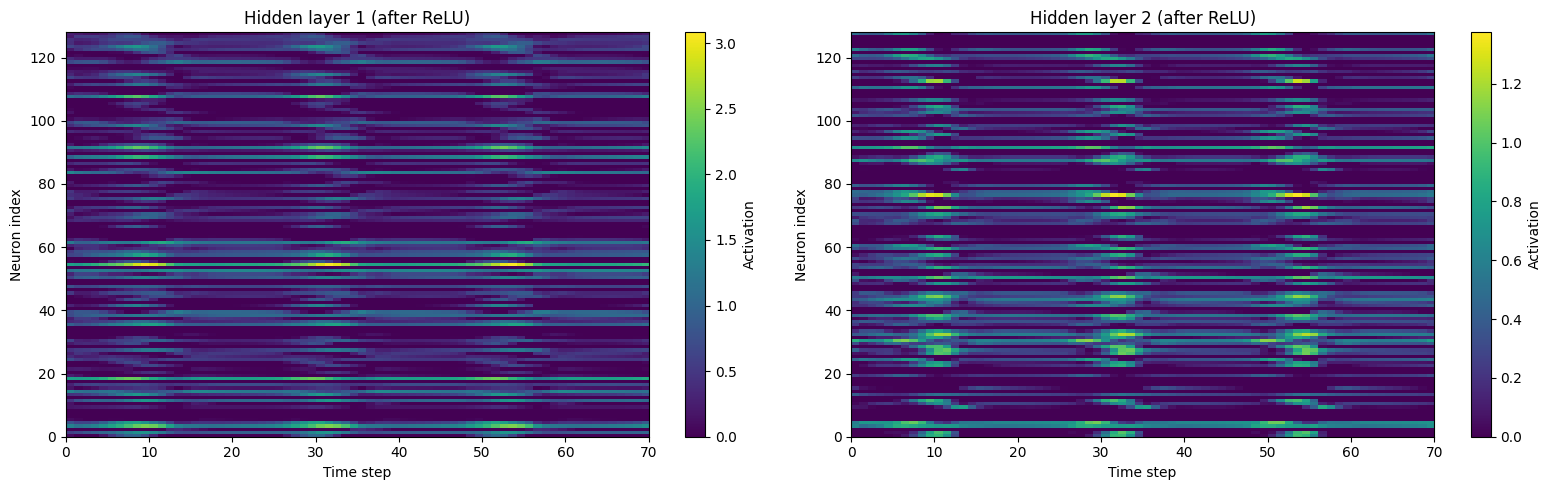

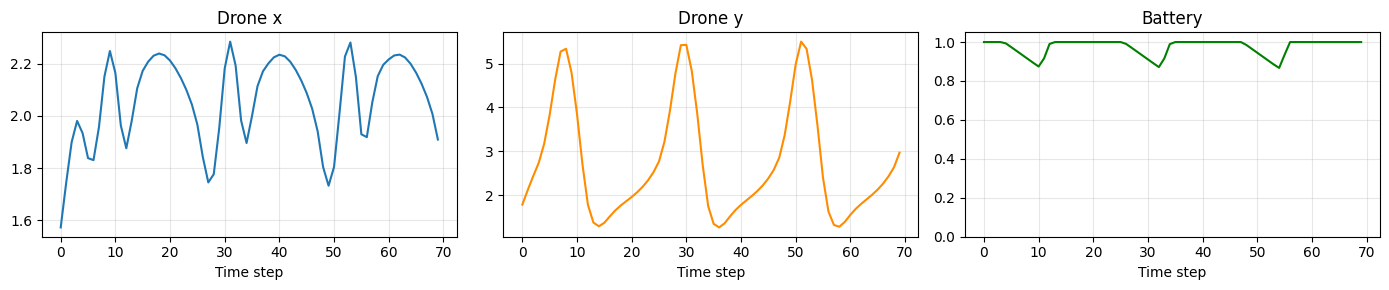

In [6]:
from drone.dynamics import _init_base_positions

# ── Build a single-episode initial state ────────────────────────────────────
cfg = ScenarioCfg(grid_side=GRID_SIDE, n_bases=N_BASES, n_drones=N_DRONES, n_feat=N_FEAT)

torch.manual_seed(42)
grid_x = torch.arange(1, GRID_SIDE + 1, dtype=torch.float32)
grid_y = torch.arange(1, GRID_SIDE + 1, dtype=torch.float32)
gx, gy = torch.meshgrid(grid_x, grid_y, indexing='ij')
grid_xy = torch.stack([gx.ravel(), gy.ravel()], dim=1).to(device)  # (n_grid, 2)

base_positions = _init_base_positions(cfg, device)                  # (n_bases, 2)

x_state = torch.zeros((1, cfg.n_nodes, cfg.n_feat), device=device)
x_state[0, :cfg.n_grid, 0:2] = grid_xy
x_state[0, :cfg.n_grid, 5]   = 2.0
x_state[0, cfg.base_slice, 0:2]  = base_positions
x_state[0, cfg.base_slice, 5]    = 0.0
x_state[0, cfg.drone_slice, 5]   = 1.0
x_state[0, cfg.drone_slice, 4]   = 1.0                             # full battery
x_state[0, cfg.drone_slice, 0:2] = torch.tensor([[1.5, 1.5]], device=device)

T_ROLLOUT = 70

# ── Hook: record activations of both ReLU layers ────────────────────────────
layer_i_key = '1'    # ReLU after first Linear
layer_ii_key = '3'   # ReLU after second Linear
rollout_acts: dict[str, list] = {layer_i_key: [], layer_ii_key: []}

rollout_hooks = []
for lname in [layer_i_key, layer_ii_key]:
    def _make_rollout_hook(k):
        def hook(m, inp, out):
            rollout_acts[k].append(out.detach().cpu().numpy()[0])  # (hidden,)
        return hook
    rollout_hooks.append(policy.net[int(lname)].register_forward_hook(_make_rollout_hook(lname)))

# ── Drone state trajectories ─────────────────────────────────────────────────
traj_x, traj_y, traj_batt = [], [], []

with torch.no_grad():
    curr = x_state.clone()
    for t in range(T_ROLLOUT):
        actions = policy(curr.squeeze(0))   # (n_drones, 2)
        curr = step_dynamics_batched(curr, actions.unsqueeze(0), cfg)
        traj_x.append(curr[0, cfg.drone_slice, 0].cpu().item())
        traj_y.append(curr[0, cfg.drone_slice, 1].cpu().item())
        traj_batt.append(curr[0, cfg.drone_slice, 4].cpu().item())

for h in rollout_hooks:
    h.remove()

# ── Plot heatmaps ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
layer_labels = {layer_i_key: 'Hidden layer 1 (after ReLU)',
                layer_ii_key: 'Hidden layer 2 (after ReLU)'}

for col, (lname, lbl) in enumerate(layer_labels.items()):
    act_mat = np.array(rollout_acts[lname]).T   # (hidden, T)
    im = axes[col].imshow(act_mat, aspect='auto', origin='lower',
                          cmap='viridis',
                          extent=[0, T_ROLLOUT, 0, HIDDEN])
    axes[col].set_title(lbl)
    axes[col].set_xlabel('Time step')
    axes[col].set_ylabel('Neuron index')
    plt.colorbar(im, ax=axes[col], label='Activation')

plt.tight_layout()
plt.show()

# ── Drone trajectory alongside ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(1, 3, figsize=(14, 3))
t_axis = np.arange(T_ROLLOUT)

ax2[0].plot(t_axis, traj_x, label='x'); ax2[0].set_title('Drone x'); ax2[0].grid(alpha=0.3)
ax2[1].plot(t_axis, traj_y, label='y', color='darkorange'); ax2[1].set_title('Drone y'); ax2[1].grid(alpha=0.3)
ax2[2].plot(t_axis, traj_batt, label='battery', color='green')
ax2[2].set_title('Battery'); ax2[2].set_ylim(0, 1.05); ax2[2].grid(alpha=0.3)

for a in ax2:
    a.set_xlabel('Time step')

plt.tight_layout()
plt.show()

## 7 · Feature Importance via Input Perturbation (Occlusion)

For each input feature we **zero it out** across the full sample batch and measure how much the mean output action magnitude changes. A large drop indicates a feature the network heavily relies on.

$$\text{score}_i = \big| \|\bar{a}\|_1 - \|\bar{a}_{x_i=0}\|_1 \big|$$

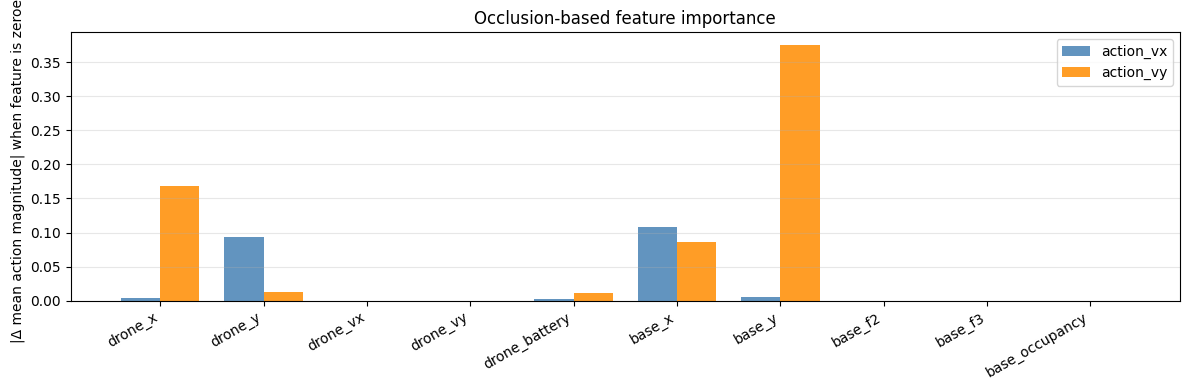


Occlusion importance ranking:
Feature                Δ action_vx   Δ action_vy    Combined
────────────────────────────────────────────────────────────
base_y                     0.00608       0.37508     0.38116
base_x                     0.10784       0.08667     0.19451
drone_x                    0.00323       0.16767     0.17090
drone_y                    0.09332       0.01285     0.10616
drone_battery              0.00279       0.01057     0.01336
base_occupancy             0.00000       0.00000     0.00000
base_f3                    0.00000       0.00000     0.00000
base_f2                    0.00000       0.00000     0.00000
drone_vx                   0.00000       0.00000     0.00000
drone_vy                   0.00000       0.00000     0.00000


In [7]:
n_features = sample_inputs.shape[1]   # 10

with torch.no_grad():
    baseline_out = policy.net(sample_inputs)              # (B, 2)
    baseline_mag = baseline_out.abs().mean(dim=0).cpu().numpy()   # (2,) — per action

occlusion_scores_vx = []
occlusion_scores_vy = []

for feat_idx in range(n_features):
    perturbed = sample_inputs.clone()
    perturbed[:, feat_idx] = 0.0   # zero-out this feature
    with torch.no_grad():
        pert_out = policy.net(perturbed)
        pert_mag = pert_out.abs().mean(dim=0).cpu().numpy()

    occlusion_scores_vx.append(abs(baseline_mag[0] - pert_mag[0]))
    occlusion_scores_vy.append(abs(baseline_mag[1] - pert_mag[1]))

occlusion_scores_vx = np.array(occlusion_scores_vx)
occlusion_scores_vy = np.array(occlusion_scores_vy)

# ── Plot ─────────────────────────────────────────────────────────────────────
x_pos = np.arange(n_features)
w = 0.38

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x_pos - w/2, occlusion_scores_vx, width=w, label='action_vx',
       color='steelblue', alpha=0.85)
ax.bar(x_pos + w/2, occlusion_scores_vy, width=w, label='action_vy',
       color='darkorange', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(INPUT_NAMES, rotation=30, ha='right')
ax.set_ylabel('|Δ mean action magnitude| when feature is zeroed')
ax.set_title('Occlusion-based feature importance')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Ranked table ─────────────────────────────────────────────────────────────
combined = occlusion_scores_vx + occlusion_scores_vy
order = np.argsort(combined)[::-1]
print("\nOcclusion importance ranking:")
print(f"{'Feature':<20}  {'Δ action_vx':>12}  {'Δ action_vy':>12}  {'Combined':>10}")
print("─" * 60)
for i in order:
    print(f"{INPUT_NAMES[i]:<20}  {occlusion_scores_vx[i]:>12.5f}  "
          f"{occlusion_scores_vy[i]:>12.5f}  {combined[i]:>10.5f}")

## 8 · Internal Representations via PCA / t-SNE

We collect the second hidden-layer activations for every state in a large set of rollout trajectories (many random starting positions and battery levels) and project them to 2D. Colour-coding by interpretable quantities reveals what structure the network has learned to separate internally.

In [8]:
N_EPISODES  = 40    # number of random starts
T_COLLECT   = 50   # steps per episode to collect

# ── Collect activations + meta info across many episodes ─────────────────────
hidden2_recordings = []   # list of (hidden,) arrays
meta_battery   = []
meta_dist2base  = []
meta_action_mag = []

# Hook only layer-index 3 (second ReLU)
_h2_buf: list = []

def _h2_hook(m, inp, out):
    _h2_buf.append(out.detach().cpu().numpy()[0])

hook_h2 = policy.net[3].register_forward_hook(_h2_hook)

torch.manual_seed(0)
for ep in range(N_EPISODES):
    # Random initial drone position and partial battery
    start_x = float(torch.FloatTensor(1).uniform_(1, GRID_SIDE))
    start_y = float(torch.FloatTensor(1).uniform_(1, GRID_SIDE))
    start_batt = float(torch.FloatTensor(1).uniform_(0.1, 1.0))

    curr = torch.zeros((1, cfg.n_nodes, cfg.n_feat), device=device)
    curr[0, :cfg.n_grid, 0:2] = grid_xy
    curr[0, :cfg.n_grid, 5]   = 2.0
    curr[0, cfg.base_slice, 0:2] = base_positions
    curr[0, cfg.base_slice, 5]   = 0.0
    curr[0, cfg.drone_slice, 5]  = 1.0
    curr[0, cfg.drone_slice, 4]  = start_batt
    curr[0, cfg.drone_slice, 0:2] = torch.tensor([[start_x, start_y]], device=device)

    with torch.no_grad():
        for t in range(T_COLLECT):
            _h2_buf.clear()
            actions = policy(curr.squeeze(0))
            curr = step_dynamics_batched(curr, actions.unsqueeze(0), cfg)

            d_pos  = curr[0, cfg.drone_slice, 0:2].cpu().numpy()[0]
            b_pos  = base_positions.cpu().numpy()[0]
            batt   = curr[0, cfg.drone_slice, 4].cpu().item()
            dist   = float(np.linalg.norm(d_pos - b_pos))
            a_mag  = float(actions.abs().mean().cpu())

            if _h2_buf:
                hidden2_recordings.append(_h2_buf[0].copy())
                meta_battery.append(batt)
                meta_dist2base.append(dist)
                meta_action_mag.append(a_mag)

hook_h2.remove()

H2 = np.array(hidden2_recordings)    # (N_points, hidden)
meta_battery   = np.array(meta_battery)
meta_dist2base = np.array(meta_dist2base)
meta_action_mag = np.array(meta_action_mag)

print(f"Collected {H2.shape[0]} hidden-layer snapshots, dimension {H2.shape[1]}")

Collected 2000 hidden-layer snapshots, dimension 128


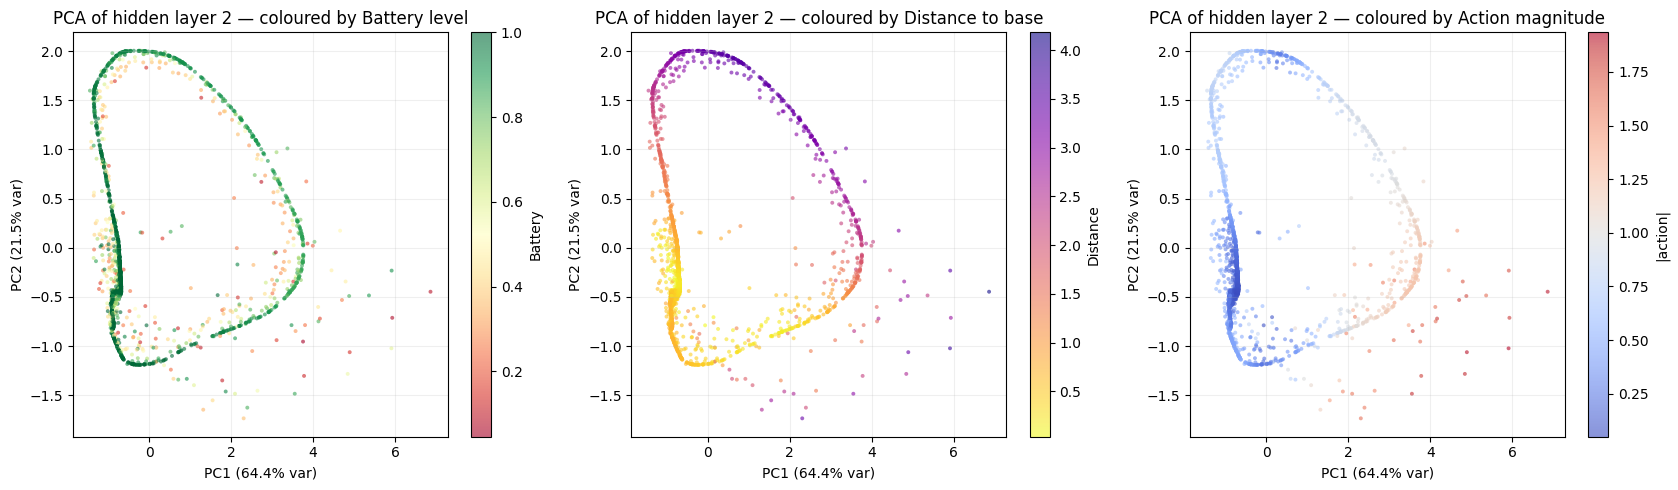

PCA explained variance: PC1=64.4%  PC2=21.5%  total=85.9%


In [9]:
# ── PCA ──────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=0)
H2_pca = pca.fit_transform(H2)

color_sources = {
    'Battery level': (meta_battery, 'RdYlGn', 'Battery'),
    'Distance to base': (meta_dist2base, 'plasma_r', 'Distance'),
    'Action magnitude': (meta_action_mag, 'coolwarm', '|action|'),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (title, (vals, cmap, clabel)) in zip(axes, color_sources.items()):
    sc = ax.scatter(H2_pca[:, 0], H2_pca[:, 1],
                    c=vals, cmap=cmap, s=8, alpha=0.6, linewidths=0)
    plt.colorbar(sc, ax=ax, label=clabel)
    ax.set_title(f'PCA of hidden layer 2 — coloured by {title}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"total={sum(pca.explained_variance_ratio_)*100:.1f}%")

Running t-SNE on 2000 points …
Done.


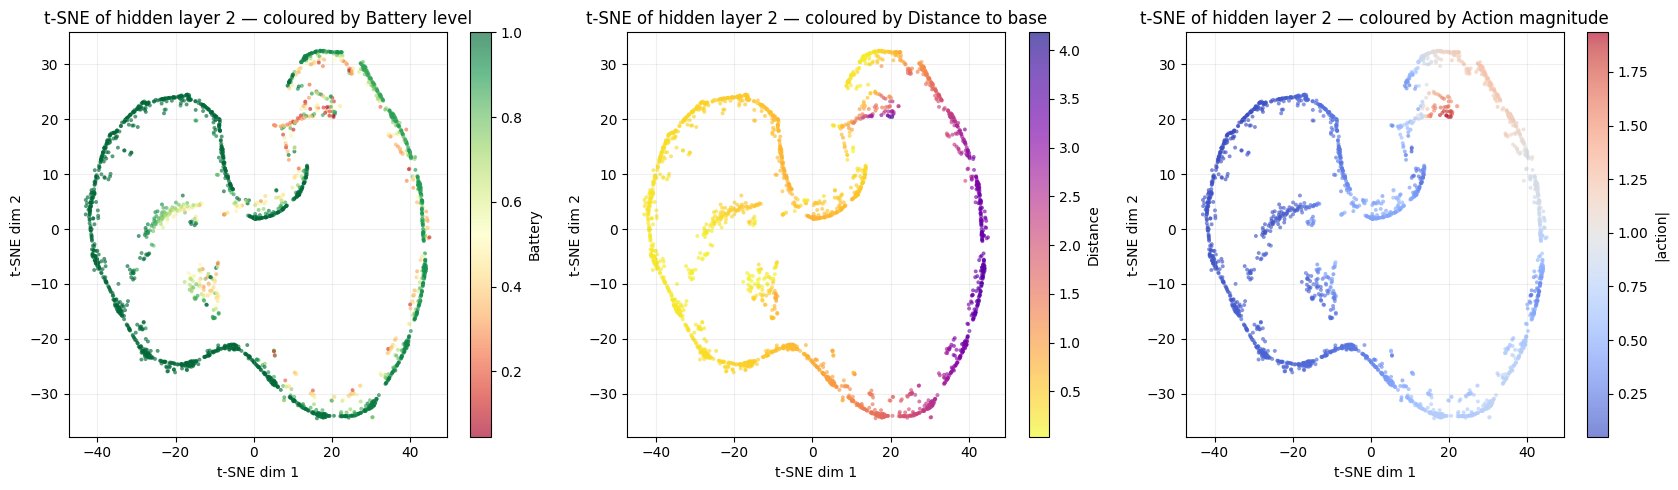

In [12]:
# ── t-SNE ────────────────────────────────────────────────────────────────────
# Sub-sample to keep runtime reasonable
MAX_TSNE = 2000
if len(H2) > MAX_TSNE:
    idx  = np.random.default_rng(42).choice(len(H2), MAX_TSNE, replace=False)
    H2_s = H2[idx]; batt_s = meta_battery[idx]
    dist_s = meta_dist2base[idx]; amag_s = meta_action_mag[idx]
else:
    H2_s = H2; batt_s = meta_battery; dist_s = meta_dist2base; amag_s = meta_action_mag

print(f"Running t-SNE on {len(H2_s)} points …")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=0,
            learning_rate='auto', init='random')
H2_tsne = tsne.fit_transform(H2_s)
print("Done.")

color_sources_s = {
    'Battery level':    (batt_s, 'RdYlGn',   'Battery'),
    'Distance to base': (dist_s, 'plasma_r',  'Distance'),
    'Action magnitude': (amag_s, 'coolwarm',  '|action|'),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (title, (vals, cmap, clabel)) in zip(axes, color_sources_s.items()):
    sc = ax.scatter(H2_tsne[:, 0], H2_tsne[:, 1],
                    c=vals, cmap=cmap, s=8, alpha=0.65, linewidths=0)
    plt.colorbar(sc, ax=ax, label=clabel)
    ax.set_title(f't-SNE of hidden layer 2 — coloured by {title}')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## Summary

| Section | Key question answered |
|---------|----------------------|
| 2 · Architecture | How many parameters? What are the layer shapes? |
| 3 · Weight distributions | Are weights spread out or concentrated near zero? Any dead filters? |
| 4 · Activation distributions | Do neurons actually fire across diverse inputs? Are there dead neurons after ReLU? |
| 5 · Gradient saliency | Which inputs have the strongest derivative influence on each action? |
| 6 · Rollout heatmaps | How do neuron activations evolve dynamically during a trajectory? |
| 7 · Perturbation importance | Which input dimensions cause the biggest behavioural change when removed? |
| 8 · PCA / t-SNE | Does the hidden space form interpretable clusters by battery, distance, or urgency? |